In [ ]:
# Instalación de Apache Spark en Google Colab
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar xf spark-3.5.0-bin-hadoop3.tgz
!pip install -q findspark
!pip install seaborn

import os
# Configuramos las variables de entorno
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

import findspark
findspark.init()

W: Operation was interrupted before it could finish
^C
^C
tar: spark-3.5.0-bin-hadoop3.tgz: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now
^C


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AnalisisEgresos2024") \
    .getOrCreate()

df = spark.read.csv(
    '/content/EGRESOS_2024.csv',
    header=True,
    inferSchema=True,
    sep=';'
)

df.show(5)

+---------------------------------+----+------------+-----------------+-----------------+-----------------------+-----------------+-----------------------+---------+---------------+----------+-----+-----+-----------+----------------+
|PERTENENCIA_ESTABLECIMIENTO_SALUD|SEXO|  GRUPO_EDAD|GLOSA_PAIS_ORIGEN|COMUNA_RESIDENCIA|GLOSA_COMUNA_RESIDENCIA|REGION_RESIDENCIA|GLOSA_REGION_RESIDENCIA|PREVISION|GLOSA_PREVISION|ANO_EGRESO|DIAG1|DIAG2|DIAS_ESTADA|CONDICION_EGRESO|
+---------------------------------+----+------------+-----------------+-----------------+-----------------------+-----------------+-----------------------+---------+---------------+----------+-----+-----+-----------+----------------+
|             Pertenecientes al...|   2|20 A 24 A�OS|        Argentina|            01101|                Iquique|               01|            De Tarapac�|        1|         FONASA|      2024| N908| NULL|          2|               1|
|             Pertenecientes al...|   2|25 A 29 A�OS|        Arg

--- 1. Estadísticas Descriptivas ---
+-------+---------------------------------+-------------------+--------------+--------------------+------------------+-----------------------+------------------+-----------------------+-----------------+---------------+----------+-------+------+------------------+-------------------+
|summary|PERTENENCIA_ESTABLECIMIENTO_SALUD|               SEXO|    GRUPO_EDAD|   GLOSA_PAIS_ORIGEN| COMUNA_RESIDENCIA|GLOSA_COMUNA_RESIDENCIA| REGION_RESIDENCIA|GLOSA_REGION_RESIDENCIA|        PREVISION|GLOSA_PREVISION|ANO_EGRESO|  DIAG1| DIAG2|       DIAS_ESTADA|   CONDICION_EGRESO|
+-------+---------------------------------+-------------------+--------------+--------------------+------------------+-----------------------+------------------+-----------------------+-----------------+---------------+----------+-------+------+------------------+-------------------+
|  count|                          1667349|            1667349|       1667349|             1667349|         

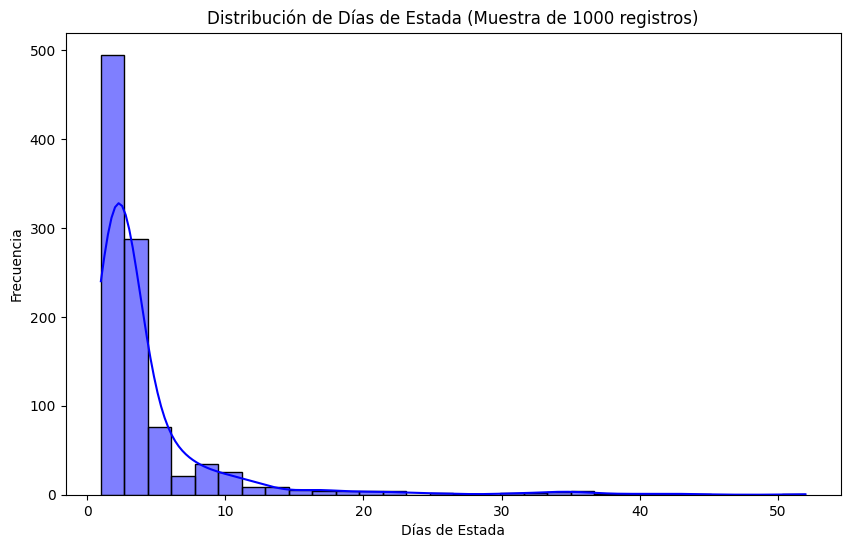

In [ ]:
#########################################
## FASE 2: ENTENDIMIENTO DE LOS DATOS  ##
#########################################

from pyspark.sql.functions import col, sum
import matplotlib.pyplot as plt
import seaborn as sns

print(" 1. Estadísticas Descriptivas ")
df.summary().show()

print("\n 2. Conteo de Valores Nulos por Columna ")
nulos_df = df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])
nulos_df.show()

print("\n 3. Verificación de Desbalance de Clases ")
df.groupBy('CONDICION_EGRESO').count().show()

print("\n 4. Asimetrías y Anomalías (Análisis Visual) ")
pdf_sample = df.limit(1000).toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(data=pdf_sample, x='DIAS_ESTADA', kde=True, color='blue', bins=30)
plt.title('Distribución de Días de Estada (Muestra de 1000 registros)')
plt.xlabel('Días de Estada')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
########################################################
## FASE 3: PREPARACIÓN DE LOS DATOS CON CLASS WEIGHTS ##
########################################################
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, MinMaxScaler
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, when, substring, lit

print(f"Total de filas iniciales: {df.count()}")

# --- 1. LIMPIEZA Y FILTRADO ---
# Eliminamos duplicados y limpiamos caracteres extraños o nulos críticos
df_clean = df.filter(
    (col("SEXO") != "*") &
    (col("GLOSA_PREVISION") != "*") &
    col("CONDICION_EGRESO").isNotNull()
).dropDuplicates().dropna(subset=['DIAG1', 'GRUPO_EDAD'])

# --- 2. INGENIERÍA DE CARACTERÍSTICAS ---
df_ml = df_clean.withColumn(
    "PREVISION_GRUPAL",
    when(col("GLOSA_PREVISION").isin("FONASA", "ISAPRE"), col("GLOSA_PREVISION")).otherwise("OTRAS_O_FF.AA")
).withColumn(
    "EDAD_SIMPLIFICADA",
    when(col("GRUPO_EDAD").rlike("MES|DIA|menor|1 A 4|5 A 9|10 A 14"), "PEDIATRICO")
    .when(col("GRUPO_EDAD").rlike("15 A 19|20 A 24|25 A 29"), "JOVEN")
    .when(col("GRUPO_EDAD").rlike("30 A 34|35 A 39|40 A 44|45 A 49|50 A 54|55 A 59"), "ADULTO")
    .otherwise("ADULTO_MAYOR")
).withColumn(
    "DIAG1_GRUPO", substring(col("DIAG1"), 1, 1)
).withColumn(
    "TIENE_DIAG2",
    when(col("DIAG2").isNull() | (col("DIAG2") == "") | (col("DIAG2") == "SIN_DIAG2"), "NO").otherwise("SI")
).withColumn(
    "DIAS_ESTADA_NUM", col("DIAS_ESTADA").cast("double")
).withColumn(
    # Etiqueta: 1.0 para fallecidos (clase de interés), 0.0 para vivos
    "label", when(col("CONDICION_EGRESO") == 2, 1.0).otherwise(0.0)
)

print(f"Total de filas tras limpieza e ingeniería: {df_ml.count()}")

# CÁLCULO DE PESOS DE CLASE (CLASS WEIGHTS)
# Contamos cuántos vivos (0.0) y fallecidos (1.0) hay en el dataset
total_rows = df_ml.count()
count_vivos = df_ml.filter(col("label") == 0.0).count()
count_fallecidos = df_ml.filter(col("label") == 1.0).count()

# Calculamos el peso ponderado (Heurística estándar: Total / (Número de clases * Casos de la clase))
peso_clase_0 = total_rows / (2 * count_vivos)
peso_clase_1 = total_rows / (2 * count_fallecidos)

print(f"Peso para clase Vivos (0.0): {peso_clase_0}")
print(f"Peso para clase Fallecidos (1.0): {peso_clase_1}")

df_ml = df_ml.withColumn("weight", when(col("label") == 0.0, lit(peso_clase_0)).otherwise(lit(peso_clase_1)))

# Pipeline
CAT_COLS = ["SEXO", "EDAD_SIMPLIFICADA", "PREVISION_GRUPAL", "DIAG1_GRUPO", "TIENE_DIAG2", "PERTENENCIA_ESTABLECIMIENTO_SALUD", "GLOSA_PAIS_ORIGEN"]
NUM_COLS = ["DIAS_ESTADA_NUM"]


indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in CAT_COLS]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe") for c in CAT_COLS]
num_assembler = VectorAssembler(inputCols=NUM_COLS, outputCol="num_features_raw")
scaler = MinMaxScaler(inputCol="num_features_raw", outputCol="scaled_num_features")
assembler_inputs = [c+"_ohe" for c in CAT_COLS] + ["scaled_num_features"]
final_assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

pipeline = Pipeline(stages=indexers + encoders + [num_assembler, scaler, final_assembler])
pipeline_model = pipeline.fit(df_ml)
df_final = pipeline_model.transform(df_ml)


train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=256)
train_data.cache()
print("\n Pipeline ejecutado exitosamente")

Total de filas iniciales: 1667349
Total de filas tras limpieza e ingeniería: 1304679
Peso para clase Vivos (0.0): 0.5152158357474798
Peso para clase Fallecidos (1.0): 16.93025096675404

--- Pipeline ejecutado exitosamente. Datos listos para la Fase 4 ---


In [ ]:
########################################################
## FASE 3: PREPARACIÓN DE LOS DATOS CON CLASS WEIGHTS ##(VERSION 3)
########################################################
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, MinMaxScaler
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, when, substring, lit

print(f"Total de filas iniciales: {df.count()}")

# --- 1. LIMPIEZA Y FILTRADO ---
# Eliminamos duplicados y limpiamos caracteres extraños o nulos críticos
df_clean = df.filter(
    (col("SEXO") != "*") &
    (col("GLOSA_PREVISION") != "*") &
    col("CONDICION_EGRESO").isNotNull()
).dropDuplicates().dropna(subset=['DIAG1', 'GRUPO_EDAD'])

# --- 2. INGENIERÍA DE CARACTERÍSTICAS ---
df_ml = df_clean.withColumn(
    "PREVISION_GRUPAL",
    when(col("GLOSA_PREVISION").isin("FONASA", "ISAPRE"), col("GLOSA_PREVISION")).otherwise("OTRAS_O_FF.AA")
).withColumn(
    "EDAD_SIMPLIFICADA",
    when(col("GRUPO_EDAD").rlike("MES|DIA|menor|1 A 4|5 A 9|10 A 14"), "PEDIATRICO")
    .when(col("GRUPO_EDAD").rlike("15 A 19|20 A 24|25 A 29"), "JOVEN")
    .when(col("GRUPO_EDAD").rlike("30 A 34|35 A 39|40 A 44|45 A 49|50 A 54|55 A 59"), "ADULTO")
    .otherwise("ADULTO_MAYOR")
).withColumn(
    "DIAG1_GRUPO", substring(col("DIAG1"), 1, 1)
).withColumn(
    "TIENE_DIAG2",
    when(col("DIAG2").isNull() | (col("DIAG2") == "") | (col("DIAG2") == "SIN_DIAG2"), "NO").otherwise("SI")
).withColumn(
    "DIAS_ESTADA_NUM", col("DIAS_ESTADA").cast("double")
).withColumn(
    # Etiqueta: 1.0 para fallecidos (nuestra clase de interés), 0.0 para vivos
    "label", when(col("CONDICION_EGRESO") == 2, 1.0).otherwise(0.0)
)

print(f"Total de filas tras limpieza e ingeniería: {df_ml.count()}")

# --- 3. CÁLCULO DE PESOS DE CLASE (CLASS WEIGHTS) ---
# Contamos cuántos vivos (0.0) y fallecidos (1.0) hay en el dataset
total_rows = df_ml.count()
count_vivos = df_ml.filter(col("label") == 0.0).count()
count_fallecidos = df_ml.filter(col("label") == 1.0).count()

# Calculamos el peso ponderado (Heurística estándar: Total / (Número de clases * Casos de la clase))
# En este caso: Número de clases = 2
peso_clase_0 = total_rows / (2 * count_vivos)
peso_clase_1 = total_rows / (2 * count_fallecidos)

print(f"Peso para clase Vivos (0.0): {peso_clase_0}")
print(f"Peso para clase Fallecidos (1.0): {peso_clase_1}")

# Asignamos el peso correspondiente a cada fila según su etiqueta
df_ml = df_ml.withColumn("weight", when(col("label") == 0.0, lit(peso_clase_0)).otherwise(lit(peso_clase_1)))

# --- 4. PIPELINE DE TRANSFORMACIÓN ---
CAT_COLS = ["SEXO", "EDAD_SIMPLIFICADA", "PREVISION_GRUPAL", "DIAG1_GRUPO", "TIENE_DIAG2", "PERTENENCIA_ESTABLECIMIENTO_SALUD", "GLOSA_PAIS_ORIGEN"]
NUM_COLS = ["DIAS_ESTADA_NUM"]

# Instanciamos los transformadores
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in CAT_COLS]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe") for c in CAT_COLS]

num_assembler = VectorAssembler(inputCols=NUM_COLS, outputCol="num_features_raw")
scaler = MinMaxScaler(inputCol="num_features_raw", outputCol="scaled_num_features")

assembler_inputs = [c+"_ohe" for c in CAT_COLS] + ["scaled_num_features"]
final_assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

# Ejecutamos el Pipeline
pipeline = Pipeline(stages=indexers + encoders + [num_assembler, scaler, final_assembler])
pipeline_model = pipeline.fit(df_ml)
df_final = pipeline_model.transform(df_ml)

# --- 5. SPLIT DE DATOS ---
train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=256)
train_data.cache()

print("\n--- Pipeline ejecutado exitosamente. Datos listos para la Fase 4 ---")

Total de filas iniciales: 1667349
Total de filas tras limpieza e ingeniería: 1304679
Peso para clase Vivos (0.0): 0.5152158357474798
Peso para clase Fallecidos (1.0): 16.93025096675404

--- Pipeline ejecutado exitosamente. Datos listos para la Fase 4 ---


In [ ]:
# ==========================================
# FASE 3: PREPARACIÓN DE LOS DATOS (ACTUALIZADA) (VERSION 2)
# ==========================================
from pyspark.ml.feature import StringIndexer, OneHotEncoder, StandardScaler, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, when, substring

print(f"Total de filas antes de limpieza: {df.count()}")

# --- A. Limpieza de Datos ---
df_clean = df.dropDuplicates()
df_clean = df_clean.dropna(subset=['DIAG1', 'CONDICION_EGRESO', 'GRUPO_EDAD'])

# --- B. Ingeniería de Características (Feature Engineering) ---
# Aquí aplicamos el tratamiento inteligente a los diagnósticos en lugar de borrarlos

df_ml = df_clean.withColumn(
    # Extraemos solo la primera letra del DIAG1 (ej: A000 -> A) para agrupar enfermedades
    "DIAG1_GRUPO", substring(col("DIAG1"), 1, 1)
).withColumn(
    # Transformamos el DIAG2 en una bandera (flag) binaria: ¿Tiene o no tiene complicación?
    "TIENE_DIAG2",
    when(col("DIAG2").isNull() | (col("DIAG2") == "") | (col("DIAG2") == "SIN_DIAG2"), "NO")
    .otherwise("SI")
)

print(f"Total de filas después de limpieza e ingeniería: {df_ml.count()}")

# --- C. Definición de Columnas a Transformar ---
# Reemplazamos 'DIAG1' por 'DIAG1_GRUPO' y agregamos la nueva variable 'TIENE_DIAG2'
columnas_categoricas = ['SEXO', 'GRUPO_EDAD', 'REGION_RESIDENCIA', 'PREVISION', 'DIAG1_GRUPO', 'TIENE_DIAG2']
columnas_numericas = ['DIAS_ESTADA']

stages = []

# --- D. Transformación de Variables Categóricas ---
for col_name in columnas_categoricas:
    indexer = StringIndexer(inputCol=col_name, outputCol=col_name+"_index", handleInvalid="keep")
    encoder = OneHotEncoder(inputCol=col_name+"_index", outputCol=col_name+"_ohe")
    stages += [indexer, encoder]

# --- E. Escalamiento de Variables Numéricas ---
assembler_num = VectorAssembler(inputCols=columnas_numericas, outputCol="num_features", handleInvalid="skip")
# Nota: Puedes usar StandardScaler (como tenías) o MinMaxScaler (como en el código sugerido). Ambos son válidos.
scaler = StandardScaler(inputCol="num_features", outputCol="scaled_num", withStd=True, withMean=False)
stages += [assembler_num, scaler]

# --- F. Consolidación Final ---
assembler_inputs = [c + "_ohe" for c in columnas_categoricas] + ["scaled_num"]
assembler_final = VectorAssembler(inputCols=assembler_inputs, outputCol="features", handleInvalid="skip")
stages += [assembler_final]

# --- G. Ejecución del Pipeline ---
pipeline = Pipeline(stages=stages)
modelo_pipeline = pipeline.fit(df_ml) # Entrenamos sobre df_ml que tiene las nuevas columnas
df_transformado = modelo_pipeline.transform(df_ml)

print("\n--- Resultado Final (Matriz de Features) ---")
df_transformado.select('CONDICION_EGRESO', 'TIENE_DIAG2', 'DIAG1_GRUPO', 'features').show(5, truncate=False)

Total de filas antes de limpieza: 1667349
Total de filas después de limpieza e ingeniería: 1320071

--- Resultado Final (Matriz de Features) ---
+----------------+-----------+-----------+-------------------------------------------------------------------------+
|CONDICION_EGRESO|TIENE_DIAG2|DIAG1_GRUPO|features                                                                 |
+----------------+-----------+-----------+-------------------------------------------------------------------------+
|1               |SI         |S          |(77,[1,19,36,44,56,75,76],[1.0,1.0,1.0,1.0,1.0,1.0,0.17664223796055828]) |
|1               |SI         |T          |(77,[0,3,36,44,62,75,76],[1.0,1.0,1.0,1.0,1.0,1.0,1.965144897311211])    |
|1               |SI         |T          |(77,[0,5,36,44,62,75,76],[1.0,1.0,1.0,1.0,1.0,1.0,0.1324816784704187])   |
|1               |SI         |S          |(77,[0,9,36,44,56,75,76],[1.0,1.0,1.0,1.0,1.0,1.0,0.1324816784704187])   |
|1               |SI         |S     

In [ ]:
# ==========================================
# FASE 3: PREPARACIÓN DE LOS DATOS (VERSION 1)
# ==========================================
from pyspark.ml.feature import StringIndexer, OneHotEncoder, StandardScaler, VectorAssembler
from pyspark.ml import Pipeline

# --- A. Limpieza de Datos ---
print(f"Total de filas antes de limpieza: {df.count()}")

# 1. Eliminar duplicados
df_clean = df.dropDuplicates()

# 2. Eliminar la columna DIAG2 porque tiene +90% de nulos
df_clean = df_clean.drop('DIAG2')

# 3. Eliminar filas con nulos en columnas críticas (por precaución)
df_clean = df_clean.dropna(subset=['DIAG1', 'CONDICION_EGRESO', 'GRUPO_EDAD'])

print(f"Total de filas después de limpieza: {df_clean.count()}")

# --- B. Definición de Columnas a Transformar ---
# Usamos las columnas reales que mostraron tus estadísticas
columnas_categoricas = ['SEXO', 'GRUPO_EDAD', 'REGION_RESIDENCIA', 'PREVISION', 'DIAG1']
columnas_numericas = ['DIAS_ESTADA']

stages = []

# --- C. Transformación de Variables Categóricas ---
for col_name in columnas_categoricas:
    # Como algunas columnas ya son números pero representan categorías (ej: SEXO 1 o 2),
    # las pasamos por StringIndexer igual para que Spark las trate como categorías
    indexer = StringIndexer(inputCol=col_name, outputCol=col_name+"_index", handleInvalid="keep")
    encoder = OneHotEncoder(inputCol=col_name+"_index", outputCol=col_name+"_ohe")
    stages += [indexer, encoder]

# --- D. Escalamiento de Variables Numéricas ---
assembler_num = VectorAssembler(inputCols=columnas_numericas, outputCol="num_features", handleInvalid="skip")
scaler = StandardScaler(inputCol="num_features", outputCol="scaled_num", withStd=True, withMean=False)
stages += [assembler_num, scaler]

# --- E. Consolidación Final ---
assembler_inputs = [c + "_ohe" for c in columnas_categoricas] + ["scaled_num"]
assembler_final = VectorAssembler(inputCols=assembler_inputs, outputCol="features", handleInvalid="skip")
stages += [assembler_final]

# --- F. Ejecución del Pipeline ---
pipeline = Pipeline(stages=stages)
modelo_pipeline = pipeline.fit(df_clean)
df_transformado = modelo_pipeline.transform(df_clean)

# Mostrar el resultado final
print("\n--- Resultado Final (Matriz de Features) ---")
df_transformado.select('CONDICION_EGRESO', 'features').show(5, truncate=False)

Total de filas antes de limpieza: 1350722
Total de filas después de limpieza: 1078213

--- Resultado Final (Matriz de Features) ---
+----------------+-----------------------------------------------------------------------+
|CONDICION_EGRESO|features                                                               |
+----------------+-----------------------------------------------------------------------+
|1               |(7079,[1,7,33,37,1355,7078],[1.0,1.0,1.0,1.0,1.0,0.02617911217568118]) |
|1               |(7079,[1,19,33,41,95,7078],[1.0,1.0,1.0,1.0,1.0,0.02617911217568118])  |
|1               |(7079,[1,13,33,37,4347,7078],[1.0,1.0,1.0,1.0,1.0,0.10471644870272472])|
|1               |(7079,[0,13,33,37,149,7078],[1.0,1.0,1.0,1.0,1.0,0.39268668263521767]) |
|1               |(7079,[0,9,33,37,2949,7078],[1.0,1.0,1.0,1.0,1.0,0.07853733652704353]) |
+----------------+-----------------------------------------------------------------------+
only showing top 5 rows
